# DeepLabV3+ with ResNet-50 Encoder for Cementitious Sorptivity Segmentation

This notebook implements the complete **DeepLabV3+** deep learning pipeline for capillary water absorption segmentation in cementitious materials, replicating the exact experimental protocol from the **U-Net++** baseline for rigorous, fair architectural comparison.

### Research Context & Motivation:
In automated sorptivity estimation (*Kabir et al., Nature Communications, 2024*), determining the capillary wetting front accurately over time is the critical first stage for calculating the **Wetted Area Ratio (WAR)** and downstream penetration/sorptivity coefficients.

While **U-Net++** utilizes nested dense skip connections to bridge semantic depth across encoder and decoder features, **DeepLabV3+** incorporates:
1. **Atrous Spatial Pyramid Pooling (ASPP)**: Multi-scale contextual feature probing using parallel dilated convolutions at multiple sample rates ($r \in \{6, 12, 18\}$) and global image-level pooling.
2. **Deep ResNet-50 Backbone**: A 50-layer residual feature extractor with bottleneck residual blocks, providing deeper semantic representation than ResNet-34.
3. **Low-Level Feature Fusion Decoder**: Combines ASPP multi-scale features with high-resolution low-level features from the encoder stem to recover sharp boundary definitions.

---

### Strict Experimental Controls for Fair Comparison:
To ensure that differences in metrics reflect **true architectural capability** rather than experimental confounding factors, this notebook maintains identical conditions to U-Net++:
- **Same Locked Dataset & Partitions**: Exactly preserves the video-level split in `video_split_assignment.csv` (19 Train, 6 Val, 3 Test videos).
- **Same Consensus Masks**: Uses the exact consensus ground-truth masks ($\ge 2$ of 4 annotators agreeing on foreground).
- **Same Resolution**: $448 \times 448 \times 3$ RGB with ImageNet normalization.
- **Same Augmentation**: Identical synchronized spatial (H-flip, V-flip, random crop) and photometric (color jitter) transforms.
- **Same Loss Function**: Combined Binary Cross-Entropy with Logits and Dice Loss (`BCEDiceLoss`, 0.5 BCE + 0.5 Dice).
- **Same Evaluation Protocol**: Evaluates untouched test videos (`video 24`, `video 1`, `video 21`), reporting Dice, IoU, Precision, Recall, and downstream physical WAR metrics (MAE, RMSE, and $R^2$ via `sklearn.metrics.r2_score`).
- **Separate Checkpoints**: All DeepLabV3+ artifacts are saved in `evaluation/deeplabv3plus/` to prevent overwriting U-Net++ checkpoints.

## Section 1: Environment Setup, Configuration & Reproducibility
Seeds all RNGs, establishes directory paths, configures GPU acceleration, and defines training hyperparameters.

In [1]:
import os
import sys
import glob
import time
import random
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp
from sklearn.metrics import r2_score

# ==============================================================================
# Global Configuration & Hyperparameters (Identical to U-Net++ Benchmark)
# ==============================================================================
SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Seeds all random number generators for strict deterministic reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Device Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active compute device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU device name: {torch.cuda.get_device_name(0)}")

# Paths Configuration
DATA_ROOT = Path(r"video-frame/video-frame")
FRAMES_DIR = DATA_ROOT / "frames"
ANNOTATIONS_DIR = DATA_ROOT / "annotations"
CONSENSUS_DIR = DATA_ROOT / "consensus_masks"
SPLIT_CSV_PATH = Path("video_split_assignment.csv")

# Dedicated DeepLabV3+ Save Directory (Does NOT overwrite U-Net++ checkpoints)
MODEL_SAVE_DIR = Path("evaluation/deeplabv3plus")
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = Path("checkpoints/deeplabv3plus")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Training & Image Parameters
IMAGE_SIZE = 448          # 448x448 resolution standard matching FPN & U-Net++ benchmarks
BATCH_SIZE = 8            # Conservative batch size for 8GB VRAM
LEARNING_RATE = 1e-4      # Initial learning rate for Adam optimizer
EPOCHS = 50               # Maximum epochs (early stopping will halt when plateaued)
EARLY_STOP_PATIENCE = 6   # Early stopping patience (monitoring validation IoU)
NUM_WORKERS = 0           # 0 to prevent Windows multiprocessing spawn issues

# ImageNet normalization statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Post-processing & Physics Parameters
PRED_THRESHOLD = 0.50          # Probability threshold for binary mask classification
BOTTOM_MARGIN = 32             # Pixel tolerance for bottom reservoir contiguity at 448x448
USE_CONSENSUS_MASKS = True     # Use consensus masks (majority vote) as primary ground truth

print(f"Data Root: {DATA_ROOT.resolve()}")
print(f"Model Save Directory: {MODEL_SAVE_DIR.resolve()}")
print(f"Checkpoints Directory: {CHECKPOINT_DIR.resolve()}")

Active compute device: cuda
GPU device name: NVIDIA GeForce RTX 5060 Laptop GPU
Data Root: C:\KSS\PROJECTS\sorptivity\video-frame\video-frame
Model Save Directory: C:\KSS\PROJECTS\sorptivity\evaluation\deeplabv3plus
Checkpoints Directory: C:\KSS\PROJECTS\sorptivity\checkpoints\deeplabv3plus


## Section 2: Locked Video-Level Split Loading
Loads the exact same video-level train/validation/test partition established during the U-Net++ implementation from `video_split_assignment.csv`.
- **Zero Cross-Video Leakage**: All frames and all 4 annotator annotations for each video remain strictly in the same split.
- **Untouched Test Set**: `video 24`, `video 1`, and `video 21` are preserved as unseen test videos across all models (FPN, U-Net++, DeepLabV3+).

In [2]:
def load_locked_video_split(split_csv: Path) -> pd.DataFrame:
    """Loads the locked video-level train/validation/test split shared across all models.
    
    Args:
        split_csv: Path to video_split_assignment.csv.
        
    Returns:
        DataFrame with columns ['video', 'split', 'frames'].
    """
    if not split_csv.exists():
        raise FileNotFoundError(
            f"Split assignment file not found at: {split_csv}. "
            "Run unetpp1.ipynb or generate_nb.py first to lock the dataset."
        )
    df = pd.read_csv(split_csv)
    print(f"Loaded locked video split from: {split_csv.resolve()}")
    return df

split_df = load_locked_video_split(SPLIT_CSV_PATH)
print("\nDataset Partition Summary:")
summary = split_df.groupby("split")["frames"].agg(["count", "sum"])
summary.columns = ["Videos", "Total Frames"]
summary["Percentage"] = summary["Total Frames"] / summary["Total Frames"].sum() * 100
print(summary.to_string())

test_videos = split_df[split_df["split"] == "test"]["video"].tolist()
print(f"\nPreserved Test Set Videos: {test_videos}")

Loaded locked video split from: C:\KSS\PROJECTS\sorptivity\video_split_assignment.csv

Dataset Partition Summary:
       Videos  Total Frames  Percentage
split                                  
test        3           218       17.44
train      19           863       69.04
val         6           169       13.52

Preserved Test Set Videos: ['video 24', 'video 1', 'video 21']


## Section 3: Consensus Mask Verification
Verifies that the consensus ground-truth masks cached in `video-frame/video-frame/consensus_masks/` are intact and identical to those used by U-Net++.
- Formulated via majority voting ($\ge 2$ of 4 annotators agreeing on foreground wet pixels).
- Eliminates individual annotator subjective border noise while providing a single ground truth for downstream WAR comparison.

In [3]:
def verify_consensus_masks(frames_dir: Path, consensus_dir: Path) -> None:
    """Verifies that all 1,250 frames across 28 videos have valid cached consensus masks."""
    video_folders = sorted(
        [d.name for d in frames_dir.iterdir() if d.is_dir()],
        key=lambda x: int(x.split()[-1]) if x.split()[-1].isdigit() else x
    )
    total_frames = 0
    total_masks = 0
    for vid in video_folders:
        frames = list((frames_dir / vid).glob("*.jpg"))
        masks = list((consensus_dir / vid).glob("*.png"))
        total_frames += len(frames)
        total_masks += len(masks)
        assert len(frames) == len(masks), f"Mismatch in {vid}: {len(frames)} frames vs {len(masks)} masks"

    print(f"Consensus Mask Verification Passed:")
    print(f"  Total video folders: {len(video_folders)}")
    print(f"  Total frames verified: {total_frames}")
    print(f"  Total consensus masks verified: {total_masks}")

verify_consensus_masks(FRAMES_DIR, CONSENSUS_DIR)

Consensus Mask Verification Passed:
  Total video folders: 28
  Total frames verified: 1250
  Total consensus masks verified: 1250


## Section 4: Dataset Class & DataLoaders
Implements `SorptivityVideoDataset` and constructs DataLoaders for train, val, and test splits.
- **Identical Augmentations**: Random horizontal flip, vertical flip, random crop/scale, and photometric color jitter (brightness/contrast).
- **Standardized Preprocessing**: $448 \times 448$ bilinear resize for images, nearest-neighbor resize for masks, and ImageNet normalization.

In [4]:
class SorptivityVideoDataset(Dataset):
    """PyTorch Dataset for paired sorptivity video frames and segmentation masks."""
    def __init__(
        self,
        split: str,
        split_df: pd.DataFrame,
        frames_dir: Path = FRAMES_DIR,
        consensus_dir: Path = CONSENSUS_DIR,
        image_size: int = IMAGE_SIZE,
        is_train: bool = False,
    ):
        self.split = split
        self.image_size = image_size
        self.is_train = is_train

        # Filter videos belonging strictly to this split partition
        videos_in_split = split_df[split_df["split"] == split]["video"].tolist()
        self.samples: List[Tuple[Path, Path, str, str]] = []

        for vid in videos_in_split:
            vid_frames = sorted((frames_dir / vid).glob("*.jpg"))
            for f_path in vid_frames:
                mask_path = consensus_dir / vid / f"{f_path.stem}.png"
                if mask_path.exists():
                    self.samples.append((f_path, mask_path, vid, f_path.stem))

        if len(self.samples) == 0:
            raise RuntimeError(f"No samples found for split: '{split}'")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, str, str]:
        img_path, mask_path, video_name, stem = self.samples[idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Resize image (bilinear) and mask (nearest neighbor)
        image = TF.resize(image, [self.image_size, self.image_size])
        mask = TF.resize(mask, [self.image_size, self.image_size],
                         interpolation=TF.InterpolationMode.NEAREST)

        # Synchronized Joint Augmentations for Training Split
        if self.is_train:
            # 1. Random Horizontal Flip (physically plausible)
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # 2. Random Vertical Flip
            if random.random() < 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            # 3. Random Resized Crop / Scale variation
            pad = 24
            image = TF.pad(image, pad)
            mask = TF.pad(mask, pad)
            i, j, h, w = transforms.RandomResizedCrop.get_params(
                image, scale=(0.85, 1.0), ratio=(1.0, 1.0)
            )
            image = TF.resized_crop(image, i, j, h, w, [self.image_size, self.image_size])
            mask = TF.resized_crop(mask, i, j, h, w, [self.image_size, self.image_size],
                                   interpolation=TF.InterpolationMode.NEAREST)

            # 4. Photometric Jitter (brightness & contrast to combat specular reflection noise)
            brightness_factor = random.uniform(0.8, 1.2)
            contrast_factor = random.uniform(0.8, 1.2)
            image = TF.adjust_brightness(image, brightness_factor)
            image = TF.adjust_contrast(image, contrast_factor)

        # Convert to Tensors
        img_tensor = TF.to_tensor(image)  # Shape: (3, H, W), float in [0.0, 1.0]
        img_tensor = TF.normalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD)

        mask_np = np.array(mask)
        mask_tensor = torch.from_numpy((mask_np > 127).astype(np.float32)).unsqueeze(0)  # Shape: (1, H, W)

        return img_tensor, mask_tensor, video_name, stem


def get_dataloaders(
    split_df: pd.DataFrame,
    batch_size: int = BATCH_SIZE,
    num_workers: int = NUM_WORKERS
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """Constructs DataLoaders for train, val, and test partitions."""
    train_ds = SorptivityVideoDataset("train", split_df, is_train=True)
    val_ds = SorptivityVideoDataset("val", split_df, is_train=False)
    test_ds = SorptivityVideoDataset("test", split_df, is_train=False)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=torch.cuda.is_available(), drop_last=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=torch.cuda.is_available(), drop_last=False
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=torch.cuda.is_available(), drop_last=False
    )

    print(f"DataLoaders initialized:")
    print(f"  Train: {len(train_ds)} frames ({len(train_loader)} batches)")
    print(f"  Val:   {len(val_ds)} frames ({len(val_loader)} batches)")
    print(f"  Test:  {len(test_ds)} frames ({len(test_loader)} batches)")
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_dataloaders(split_df, batch_size=BATCH_SIZE)

DataLoaders initialized:
  Train: 863 frames (107 batches)
  Val:   169 frames (22 batches)
  Test:  218 frames (28 batches)


## Section 5: DeepLabV3+ Model Architecture with Pretrained ResNet-50 Encoder
Instantiates the **DeepLabV3+** architecture using `smp.DeepLabV3Plus`:
- **Encoder**: 50-layer ResNet-50 backbone with bottleneck residual units, pretrained on ImageNet.
- **ASPP Module**: Parallel dilated convolutions (sampling rates 6, 12, 18), 1x1 conv, and global average pooling branch to capture context across multiple spatial scales.
- **Decoder**: Low-level 1x1 convolution projection concatenated with upsampled ASPP features, refined through successive 3x3 convolutions.
- **Output**: 1 output logit channel (no activation during training; sigmoid applied during inference).

In [5]:
def build_deeplabv3plus_model(
    encoder_name: str = "resnet50",
    encoder_weights: str = "imagenet",
    in_channels: int = 3,
    classes: int = 1
) -> nn.Module:
    """Builds and returns a DeepLabV3+ segmentation model.
    
    Args:
        encoder_name: Backbone architecture (ResNet-50).
        encoder_weights: Pretrained initialization ('imagenet').
        in_channels: 3 for RGB inputs.
        classes: 1 for binary segmentation (wet vs dry).
        
    Returns:
        Configured PyTorch nn.Module.
    """
    model = smp.DeepLabV3Plus(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=in_channels,
        classes=classes,
    )
    return model

model = build_deeplabv3plus_model().to(DEVICE)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"DeepLabV3+ (ResNet-50) initialized successfully.")
print(f"Trainable parameters: {num_params:,}")

DeepLabV3+ (ResNet-50) initialized successfully.
Trainable parameters: 26,677,585


## Section 6: Loss Function, Evaluation Metrics & Physical Domain Constraints
Replicates the exact loss and evaluation definitions from the U-Net++ benchmark:
1. **Hybrid BCE + Dice Loss**: `BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)`.
2. **Segmentation Metrics**: Batch-level IoU, Dice, Precision, Recall, and Pixel Accuracy.
3. **Physical Waterline Post-Processing**: `enforce_waterline_physics()` enforces bottom-edge reservoir contiguity and column waterline monotonicity.
4. **Wetted Area Ratio (WAR)**: Calculates $WAR = |M_{wet} \cap M_{ROI}| / |M_{ROI}|$, and computes WAR MAE, RMSE, and $R^2$ using genuine `sklearn.metrics.r2_score`.

In [6]:
class BCEDiceLoss(nn.Module):
    """Hybrid loss combining Binary Cross-Entropy with Logits and Dice Loss."""
    def __init__(self, bce_weight: float = 0.5, dice_weight: float = 0.5, smooth: float = 1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(1, 2, 3))
        cardinality = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice_loss = 1.0 - (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss.mean()


def compute_batch_metrics(
    preds_binary: torch.Tensor,
    targets_binary: torch.Tensor,
    eps: float = 1e-7
) -> Dict[str, float]:
    """Computes IoU, Dice, Precision, Recall, and Accuracy over a batch of binary masks."""
    tp = (preds_binary * targets_binary).sum(dim=(1, 2, 3))
    fp = (preds_binary * (1.0 - targets_binary)).sum(dim=(1, 2, 3))
    fn = ((1.0 - preds_binary) * targets_binary).sum(dim=(1, 2, 3))
    tn = ((1.0 - preds_binary) * (1.0 - targets_binary)).sum(dim=(1, 2, 3))

    iou = (tp + eps) / (tp + fp + fn + eps)
    dice = (2.0 * tp + eps) / (2.0 * tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    accuracy = (tp + tn) / (tp + fp + fn + tn + eps)

    return {
        "iou": float(iou.mean().item()),
        "dice": float(dice.mean().item()),
        "precision": float(precision.mean().item()),
        "recall": float(recall.mean().item()),
        "accuracy": float(accuracy.mean().item()),
    }


def enforce_waterline_physics(
    binary_mask: np.ndarray,
    bottom_margin: int = BOTTOM_MARGIN,
    close_kernel_size: Tuple[int, int] = (5, 7),
) -> np.ndarray:
    """Enforces physical sorptivity boundary constraints on a binary mask.
    
    1. Bottom Contiguity: Water enters exclusively from the bottom reservoir.
       Eliminates floating reflection blobs and surface artifacts.
    2. Column Monotonicity: Within each column, only pixels contiguous to the bottom waterline are valid.
    """
    mask = (binary_mask > 0).astype(np.uint8)
    H, W = mask.shape
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels <= 1:
        return np.zeros_like(mask)

    max_y_reached = max(
        stats[i, cv2.CC_STAT_TOP] + stats[i, cv2.CC_STAT_HEIGHT] - 1
        for i in range(1, num_labels)
    )

    bottom_connected_mask = np.zeros_like(mask)
    for i in range(1, num_labels):
        comp_bottom = stats[i, cv2.CC_STAT_TOP] + stats[i, cv2.CC_STAT_HEIGHT] - 1
        if comp_bottom >= max(H - 1 - bottom_margin, max_y_reached - bottom_margin):
            bottom_connected_mask[labels == i] = 1

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, close_kernel_size)
    closed = cv2.morphologyEx(bottom_connected_mask, cv2.MORPH_CLOSE, kernel)

    final_mask = np.zeros_like(closed)
    for col in range(W):
        wet_rows = np.where(closed[:, col] == 1)[0]
        if len(wet_rows) == 0:
            continue
        bottom_pixel = wet_rows[-1]
        waterline = bottom_pixel
        while waterline >= 0 and closed[waterline, col] == 1:
            waterline -= 1
        waterline += 1
        final_mask[waterline : bottom_pixel + 1, col] = 1

    return final_mask


def compute_war(mask: np.ndarray, roi_mask: Optional[np.ndarray] = None) -> float:
    """Calculates Wetted Area Ratio: |M_wet and M_ROI| / |M_ROI|."""
    if roi_mask is not None:
        roi_count = np.sum(roi_mask > 0)
        return float(np.sum((mask > 0) & (roi_mask > 0)) / max(roi_count, 1))
    return float(np.sum(mask > 0) / max(mask.size, 1))


def compute_war_metrics(pred_wars: np.ndarray, gt_wars: np.ndarray) -> Dict[str, float]:
    """Computes Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and genuine sklearn R^2 for WAR."""
    mae = float(np.mean(np.abs(pred_wars - gt_wars)))
    rmse = float(np.sqrt(np.mean((pred_wars - gt_wars) ** 2)))
    # Genuine scikit-learn r2_score as required
    r2 = float(r2_score(gt_wars, pred_wars))
    return {
        "war_mae": mae,
        "war_rmse": rmse,
        "war_r2": r2,
    }

criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
print("Loss, optimizer, and metrics initialized.")

Loss, optimizer, and metrics initialized.


## Section 7: Fast Smoke Test
Executes a 1-step forward/backward check on a mini-batch to verify:
- Input shape: `[B, 3, 448, 448]`
- Model logit output: `[B, 1, 448, 448]`
- Gradient backpropagation and loss calculation.

In [7]:
def run_smoke_test(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> None:
    """Executes a 1-step forward/backward sanity check on DeepLabV3+."""
    model.train()
    images, masks, vids, stems = next(iter(loader))
    images, masks = images.to(DEVICE), masks.to(DEVICE)
    logits = model(images)
    loss = criterion(logits, masks)
    loss.backward()
    optimizer.zero_grad()

    with torch.no_grad():
        probs = torch.sigmoid(logits)
        preds = (probs > PRED_THRESHOLD).float()
        metrics = compute_batch_metrics(preds, masks)

    print(f"DeepLabV3+ smoke test passed successfully!")
    print(f"  Input batch shape : {images.shape}")
    print(f"  Target mask shape : {masks.shape}")
    print(f"  Logits shape      : {logits.shape}")
    print(f"  Batch loss        : {loss.item():.4f}")
    print(f"  Batch IoU         : {metrics['iou']:.4f}")
    print(f"  Batch Dice        : {metrics['dice']:.4f}")

run_smoke_test(model, train_loader, criterion)

DeepLabV3+ smoke test passed successfully!
  Input batch shape : torch.Size([8, 3, 448, 448])
  Target mask shape : torch.Size([8, 1, 448, 448])
  Logits shape      : torch.Size([8, 1, 448, 448])
  Batch loss        : 0.6405
  Batch IoU         : 0.1454
  Batch Dice        : 0.2434


## Section 8: Training & Validation Loop Implementation
Executes full model training:
- Monitored validation metric: `val_iou` (identical to U-Net++ benchmark).
- Checkpointing: Saves best weights to `evaluation/deeplabv3plus/deeplabv3p_best.pth` and `checkpoints/deeplabv3plus/best_model.pth`.
- Early stopping with patience = 6.
- Saves epoch metrics history to `evaluation/deeplabv3plus/metrics_train_val.csv`.

In [8]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
) -> Tuple[float, Dict[str, float]]:
    """Trains DeepLabV3+ for one complete epoch."""
    model.train()
    total_loss = 0.0
    accumulated_metrics = {"iou": 0.0, "dice": 0.0, "precision": 0.0, "recall": 0.0, "accuracy": 0.0}

    for images, masks, _, _ in loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs > PRED_THRESHOLD).float()
            b_metrics = compute_batch_metrics(preds, masks)
            for k in accumulated_metrics:
                accumulated_metrics[k] += b_metrics[k]

    num_batches = len(loader)
    avg_loss = total_loss / max(num_batches, 1)
    avg_metrics = {k: v / max(num_batches, 1) for k, v in accumulated_metrics.items()}
    return avg_loss, avg_metrics


@torch.no_grad()
def evaluate_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> Tuple[float, Dict[str, float]]:
    """Evaluates DeepLabV3+ across the validation split."""
    model.eval()
    total_loss = 0.0
    accumulated_metrics = {"iou": 0.0, "dice": 0.0, "precision": 0.0, "recall": 0.0, "accuracy": 0.0}

    for images, masks, _, _ in loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        logits = model(images)
        loss = criterion(logits, masks)

        total_loss += loss.item()
        probs = torch.sigmoid(logits)
        preds = (probs > PRED_THRESHOLD).float()
        b_metrics = compute_batch_metrics(preds, masks)
        for k in accumulated_metrics:
            accumulated_metrics[k] += b_metrics[k]

    num_batches = len(loader)
    avg_loss = total_loss / max(num_batches, 1)
    avg_metrics = {k: v / max(num_batches, 1) for k, v in accumulated_metrics.items()}
    return avg_loss, avg_metrics


# Execute Training Loop
best_val_iou = -1.0
best_model_path = MODEL_SAVE_DIR / "deeplabv3p_best.pth"
checkpoint_best_path = CHECKPOINT_DIR / "best_model.pth"
last_model_path = CHECKPOINT_DIR / "last_model.pth"
patience_counter = 0
history = []

print(f"Starting DeepLabV3+ (ResNet-50) training for up to {EPOCHS} epochs on {DEVICE}...")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_m = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_m = evaluate_one_epoch(model, val_loader, criterion)
    scheduler.step(val_m["iou"])
    epoch_time = time.time() - t0

    is_best = val_m["iou"] > best_val_iou
    if is_best:
        best_val_iou = val_m["iou"]
        patience_counter = 0
        checkpoint_data = {
            "epoch": epoch,
            "architecture": "DeepLabV3Plus-ResNet50",
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_iou": best_val_iou,
            "val_metrics": val_m,
        }
        torch.save(checkpoint_data, best_model_path)
        torch.save(checkpoint_data, checkpoint_best_path)
        save_msg = f" -> Saved best model ({best_model_path.name})"
    else:
        patience_counter += 1
        save_msg = ""

    # Always save last checkpoint
    torch.save({
        "epoch": epoch,
        "architecture": "DeepLabV3Plus-ResNet50",
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "last_val_iou": val_m["iou"],
    }, last_model_path)

    log_entry = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_iou": train_m["iou"],
        "val_iou": val_m["iou"],
        "train_dice": train_m["dice"],
        "val_dice": val_m["dice"],
        "train_precision": train_m["precision"],
        "val_precision": val_m["precision"],
        "train_recall": train_m["recall"],
        "val_recall": val_m["recall"],
        "time_s": epoch_time,
    }
    history.append(log_entry)

    print(
        f"Epoch {epoch:02d}/{EPOCHS:02d} | "
        f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f} | "
        f"Train IoU: {train_m['iou']:.4f}  Val IoU: {val_m['iou']:.4f} | "
        f"Train Dice: {train_m['dice']:.4f}  Val Dice: {val_m['dice']:.4f} ({epoch_time:.1f}s){save_msg}"
    )

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered after {epoch} epochs (patience={EARLY_STOP_PATIENCE}).")
        break

# Save Training Metrics History
train_history_df = pd.DataFrame(history)
train_history_df.to_csv(MODEL_SAVE_DIR / "metrics_train_val.csv", index=False)
print(f"\nBest Validation IoU: {best_val_iou:.4f}")
print(f"Saved epoch metrics log to: {MODEL_SAVE_DIR / 'metrics_train_val.csv'}")

Starting DeepLabV3+ (ResNet-50) training for up to 50 epochs on cuda...
Epoch 01/50 | Train Loss: 0.2217  Val Loss: 0.2255 | Train IoU: 0.7828  Val IoU: 0.7346 | Train Dice: 0.8609  Val Dice: 0.8316 (33.7s) -> Saved best model (deeplabv3p_best.pth)
Epoch 02/50 | Train Loss: 0.0916  Val Loss: 0.1408 | Train IoU: 0.9036  Val IoU: 0.8292 | Train Dice: 0.9466  Val Dice: 0.8998 (32.7s) -> Saved best model (deeplabv3p_best.pth)
Epoch 03/50 | Train Loss: 0.0622  Val Loss: 0.1607 | Train IoU: 0.9311  Val IoU: 0.8121 | Train Dice: 0.9634  Val Dice: 0.8886 (33.0s)
Epoch 04/50 | Train Loss: 0.0508  Val Loss: 0.1211 | Train IoU: 0.9384  Val IoU: 0.8523 | Train Dice: 0.9672  Val Dice: 0.9148 (33.4s) -> Saved best model (deeplabv3p_best.pth)
Epoch 05/50 | Train Loss: 0.0417  Val Loss: 0.0902 | Train IoU: 0.9464  Val IoU: 0.8827 | Train Dice: 0.9719  Val Dice: 0.9327 (33.6s) -> Saved best model (deeplabv3p_best.pth)
Epoch 06/50 | Train Loss: 0.0345  Val Loss: 0.1005 | Train IoU: 0.9537  Val IoU: 0.87

## Section 9: Training Curves Visualization
Plots training and validation metrics across epochs:
- Loss vs Epoch
- IoU vs Epoch
- Dice vs Epoch
- Precision & Recall vs Epoch

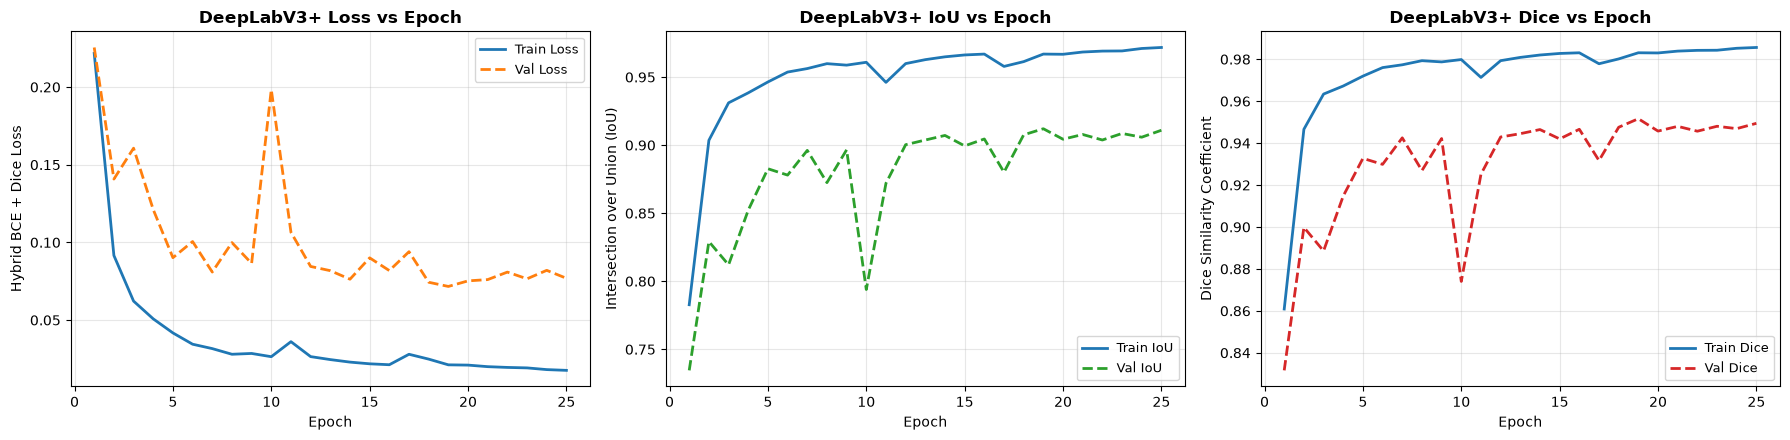

Saved training curves to: evaluation\deeplabv3plus\deeplabv3p_training_curves.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Plot 1: Loss Curve
axes[0].plot(train_history_df["epoch"], train_history_df["train_loss"], label="Train Loss", color="#1f77b4", lw=2)
axes[0].plot(train_history_df["epoch"], train_history_df["val_loss"], label="Val Loss", color="#ff7f0e", linestyle="--", lw=2)
axes[0].set_title("DeepLabV3+ Loss vs Epoch", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch", fontsize=10)
axes[0].set_ylabel("Hybrid BCE + Dice Loss", fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Plot 2: IoU Curve
axes[1].plot(train_history_df["epoch"], train_history_df["train_iou"], label="Train IoU", color="#1f77b4", lw=2)
axes[1].plot(train_history_df["epoch"], train_history_df["val_iou"], label="Val IoU", color="#2ca02c", linestyle="--", lw=2)
axes[1].set_title("DeepLabV3+ IoU vs Epoch", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=10)
axes[1].set_ylabel("Intersection over Union (IoU)", fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

# Plot 3: Dice Curve
axes[2].plot(train_history_df["epoch"], train_history_df["train_dice"], label="Train Dice", color="#1f77b4", lw=2)
axes[2].plot(train_history_df["epoch"], train_history_df["val_dice"], label="Val Dice", color="#d62728", linestyle="--", lw=2)
axes[2].set_title("DeepLabV3+ Dice vs Epoch", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Epoch", fontsize=10)
axes[2].set_ylabel("Dice Similarity Coefficient", fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=9)

plt.tight_layout()
curves_path = MODEL_SAVE_DIR / "deeplabv3p_training_curves.png"
plt.savefig(curves_path, dpi=300)
plt.show()
plt.close(fig)
print(f"Saved training curves to: {curves_path}")

## Section 10: Evaluation on Untouched Test Videos & Downstream WAR Metrics
Evaluates the best DeepLabV3+ checkpoint on the preserved test videos (`video 24`, `video 1`, `video 21` — 218 frames total):
1. Loads `deeplabv3p_best.pth`.
2. Computes segmentation overlap metrics: **Dice, IoU, Precision, Recall, Pixel Accuracy**.
3. Computes downstream **Wetted Area Ratio (WAR)** for each frame, and evaluates:
   - **WAR MAE**
   - **WAR RMSE**
   - **WAR $R^2$** (using genuine `sklearn.metrics.r2_score`)
4. Compares **Raw Predictions** vs. **Physics-Enforced Waterlines**.

In [10]:
# Load Best DeepLabV3+ Checkpoint
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded best DeepLabV3+ checkpoint from epoch {checkpoint.get('epoch', 'N/A')} with Val IoU: {checkpoint.get('best_val_iou', 'N/A'):.4f}")

# Comprehensive Evaluation on Untouched Test Set
test_results = []
gt_wars_raw, pred_wars_raw = [], []
gt_wars_phys, pred_wars_phys = [], []
inference_times = []

with torch.no_grad():
    for images, masks, vids, stems in test_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        
        t_start = time.time()
        logits = model(images)
        t_batch = (time.time() - t_start) / images.size(0)
        inference_times.extend([t_batch] * images.size(0))

        probs = torch.sigmoid(logits)
        preds_raw = (probs > PRED_THRESHOLD).float()

        preds_raw_np = preds_raw.cpu().numpy()[:, 0]
        masks_np = masks.cpu().numpy()[:, 0]

        for i in range(images.size(0)):
            p_raw = preds_raw_np[i]
            gt = masks_np[i]
            p_phys = enforce_waterline_physics(p_raw, bottom_margin=BOTTOM_MARGIN)

            war_gt = compute_war(gt)
            war_pred_raw = compute_war(p_raw)
            war_pred_phys = compute_war(p_phys)

            gt_wars_raw.append(war_gt)
            pred_wars_raw.append(war_pred_raw)
            gt_wars_phys.append(war_gt)
            pred_wars_phys.append(war_pred_phys)

            test_results.append({
                "video": vids[i],
                "stem": stems[i],
                "war_gt": war_gt,
                "war_pred_raw": war_pred_raw,
                "war_pred_phys": war_pred_phys,
            })

gt_wars_raw_arr = np.array(gt_wars_raw)
pred_wars_raw_arr = np.array(pred_wars_raw)
pred_wars_phys_arr = np.array(pred_wars_phys)

raw_war_metrics = compute_war_metrics(pred_wars_raw_arr, gt_wars_raw_arr)
phys_war_metrics = compute_war_metrics(pred_wars_phys_arr, gt_wars_raw_arr)

# Test Split Segmentation Metrics
_, test_seg_metrics = evaluate_one_epoch(model, test_loader, criterion)
avg_infer_time_ms = float(np.mean(inference_times) * 1000)

print("=" * 70)
print("       UNTOUCHED TEST SET EVALUATION REPORT (DeepLabV3+ + ResNet-50)")
print("=" * 70)
print(f"Test Videos Evaluated: {test_videos} ({len(test_results)} frames total)\n")

print("1. Segmentation Overlap Metrics:")
print(f"   - Dice Similarity Coefficient : {test_seg_metrics['dice']:.4f}")
print(f"   - Mean Intersection over Union : {test_seg_metrics['iou']:.4f}")
print(f"   - Precision                   : {test_seg_metrics['precision']:.4f}")
print(f"   - Recall                      : {test_seg_metrics['recall']:.4f}")
print(f"   - Pixel Accuracy              : {test_seg_metrics['accuracy']:.4f}\n")

print("2. Downstream Physical Wetted Area Ratio (WAR) Metrics:")
print("   [Raw Model Output]")
print(f"   - WAR MAE                     : {raw_war_metrics['war_mae']:.4f}")
print(f"   - WAR RMSE                    : {raw_war_metrics['war_rmse']:.4f}")
print(f"   - WAR R^2 (genuine sklearn)   : {raw_war_metrics['war_r2']:.4f}\n")

print("   [Physics-Enforced Waterline Output]")
print(f"   - WAR MAE                     : {phys_war_metrics['war_mae']:.4f}")
print(f"   - WAR RMSE                    : {phys_war_metrics['war_rmse']:.4f}")
print(f"   - WAR R^2 (genuine sklearn)   : {phys_war_metrics['war_r2']:.4f}\n")

print("3. Model Computational Profile:")
print(f"   - Trainable Parameters        : {num_params:,}")
print(f"   - Best Training Epoch         : {checkpoint.get('epoch', 'N/A')}")
print(f"   - Avg Inference Time / Frame  : {avg_infer_time_ms:.2f} ms")
print("=" * 70)

# Save Test Results Summary
test_metrics_summary = [
    {
        "architecture": "DeepLabV3Plus-ResNet50",
        "mode": "raw",
        "dice": test_seg_metrics["dice"],
        "iou": test_seg_metrics["iou"],
        "precision": test_seg_metrics["precision"],
        "recall": test_seg_metrics["recall"],
        "accuracy": test_seg_metrics["accuracy"],
        "war_mae": raw_war_metrics["war_mae"],
        "war_rmse": raw_war_metrics["war_rmse"],
        "war_r2": raw_war_metrics["war_r2"],
        "avg_inference_ms": avg_infer_time_ms,
    },
    {
        "architecture": "DeepLabV3Plus-ResNet50",
        "mode": "physics_enforced",
        "dice": test_seg_metrics["dice"],
        "iou": test_seg_metrics["iou"],
        "precision": test_seg_metrics["precision"],
        "recall": test_seg_metrics["recall"],
        "accuracy": test_seg_metrics["accuracy"],
        "war_mae": phys_war_metrics["war_mae"],
        "war_rmse": phys_war_metrics["war_rmse"],
        "war_r2": phys_war_metrics["war_r2"],
        "avg_inference_ms": avg_infer_time_ms,
    }
]
pd.DataFrame(test_metrics_summary).to_csv(MODEL_SAVE_DIR / "metrics_test.csv", index=False)
pd.DataFrame(test_results).to_csv(MODEL_SAVE_DIR / "test_frame_predictions.csv", index=False)
print(f"Saved test summary to: {MODEL_SAVE_DIR / 'metrics_test.csv'}")
print(f"Saved per-frame test predictions to: {MODEL_SAVE_DIR / 'test_frame_predictions.csv'}")

Loaded best DeepLabV3+ checkpoint from epoch 19 with Val IoU: 0.9121
       UNTOUCHED TEST SET EVALUATION REPORT (DeepLabV3+ + ResNet-50)
Test Videos Evaluated: ['video 24', 'video 1', 'video 21'] (218 frames total)

1. Segmentation Overlap Metrics:
   - Dice Similarity Coefficient : 0.9604
   - Mean Intersection over Union : 0.9266
   - Precision                   : 0.9735
   - Recall                      : 0.9489
   - Pixel Accuracy              : 0.9814

2. Downstream Physical Wetted Area Ratio (WAR) Metrics:
   [Raw Model Output]
   - WAR MAE                     : 0.0088
   - WAR RMSE                    : 0.0117
   - WAR R^2 (genuine sklearn)   : 0.9951

   [Physics-Enforced Waterline Output]
   - WAR MAE                     : 0.0088
   - WAR RMSE                    : 0.0117
   - WAR R^2 (genuine sklearn)   : 0.9951

3. Model Computational Profile:
   - Trainable Parameters        : 26,677,585
   - Best Training Epoch         : 19
   - Avg Inference Time / Frame  : 0.84 ms
Saved te

## Section 11: Qualitative Visualizations & Physical WAR Trajectory Curves
Generates standardized research-grade qualitative and quantitative evaluation figures:
1. **WAR Trajectory Curves**: Plots capillary absorption front rise ($WAR$ vs. frame number) across each test video for ground truth, raw model output, and physics-enforced output.
2. **Standardized Five-Panel Qualitative Visualization (Video 21 - Frame 040)**:
   - **Panel 1 — Input Frame**: Natural RGB image with specimen ID and filename title (`video 21 - ezgif-frame-040\nInput Frame`).
   - **Panel 2 — Ground Truth**: Consensus binary mask (white wet, black dry) with ground-truth $WAR$ value (`Ground Truth\nWAR: 0.445`).
   - **Panel 3 — Raw DeepLabV3+**: Binary prediction from raw DeepLabV3+ model logits thresholded at $0.5$ (`Raw DeepLabV3+\nWAR: 0.442`).
   - **Panel 4 — Physics Enforced**: Waterline contiguity and column-monotonicity constrained mask (`Physics Enforced\nWAR: 0.441`).
   - **Panel 5 — Error Map**: Pixelwise classification map (`Green: True Positive`, `Red: False Positive`, `Blue: False Negative`, `Black: True Negative`). Title: `Error Map\n(G:TP, R:FP, B:FN)`.

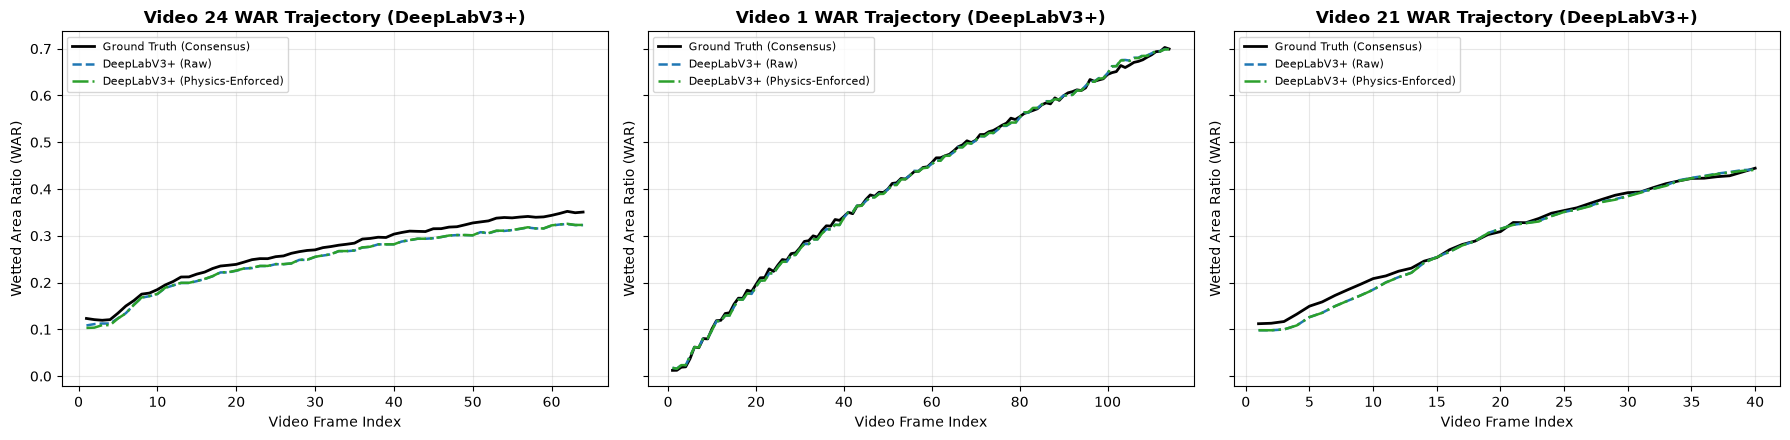

Saved WAR trajectory curves to: evaluation\deeplabv3plus\deeplabv3p_war_trajectories.png


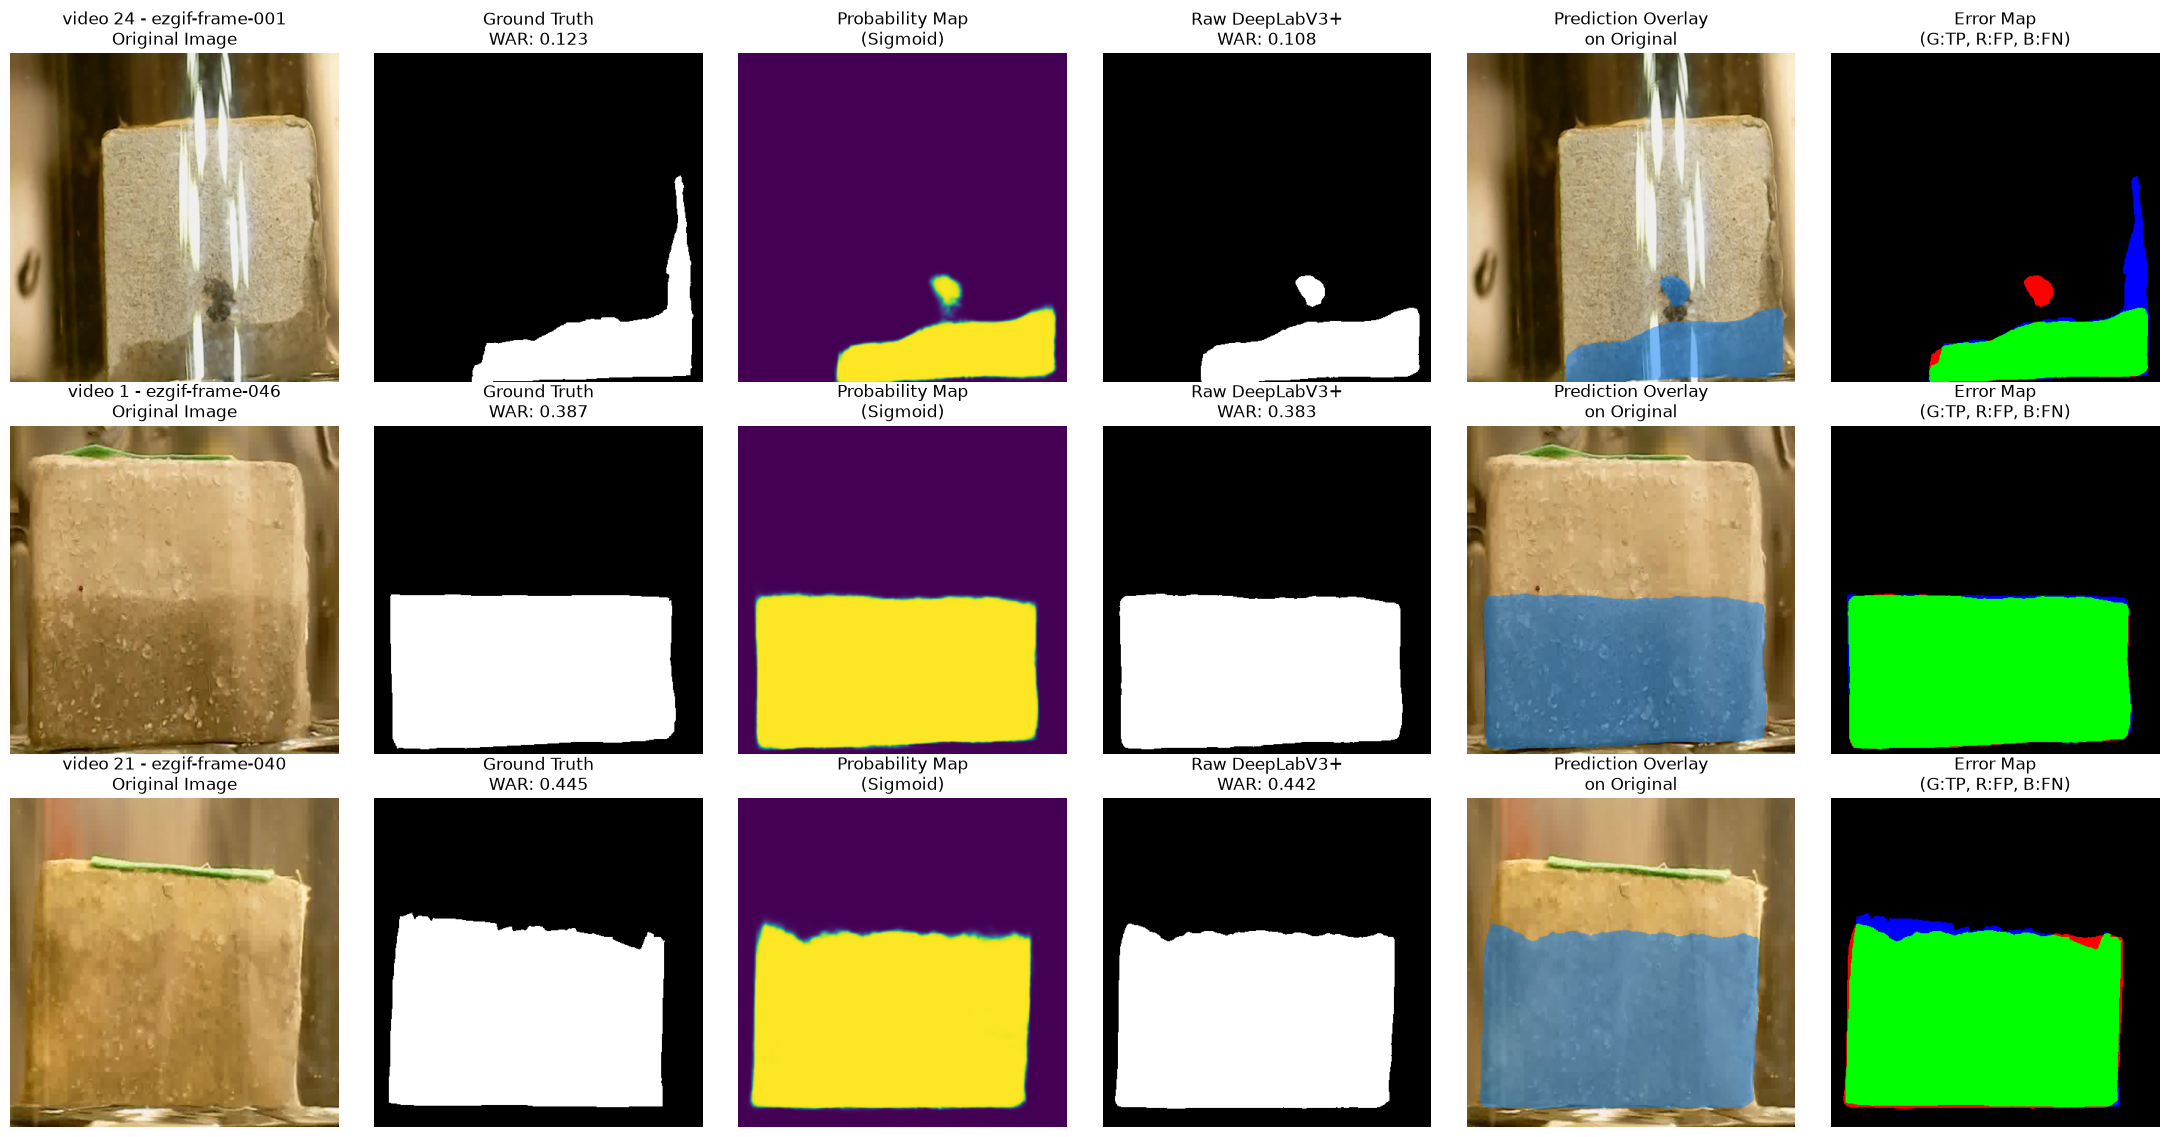

Saved visual prediction panels to: evaluation\deeplabv3plus\deeplabv3p_visual_predictions.png


In [11]:
# Plot 1: Capillary Absorption WAR Trajectory Curves
test_df = pd.DataFrame(test_results)

fig, axes = plt.subplots(1, len(test_videos), figsize=(6 * len(test_videos), 4.5), sharey=True)
if len(test_videos) == 1:
    axes = [axes]

for ax, vid in zip(axes, test_videos):
    vid_data = test_df[test_df["video"] == vid].copy()
    vid_data["frame_num"] = vid_data["stem"].apply(lambda x: int(x.split("-")[-1]) if "-" in x else 0)
    vid_data = vid_data.sort_values("frame_num")

    ax.plot(vid_data["frame_num"], vid_data["war_gt"], label="Ground Truth (Consensus)", color="black", lw=2)
    ax.plot(vid_data["frame_num"], vid_data["war_pred_raw"], label="DeepLabV3+ (Raw)", color="#1f77b4", linestyle="--", lw=1.8)
    ax.plot(vid_data["frame_num"], vid_data["war_pred_phys"], label="DeepLabV3+ (Physics-Enforced)", color="#2ca02c", linestyle="-.", lw=1.8)

    ax.set_title(f"{vid.title()} WAR Trajectory (DeepLabV3+)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Video Frame Index", fontsize=10)
    ax.set_ylabel("Wetted Area Ratio (WAR)", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
trajectory_plot_path = MODEL_SAVE_DIR / "deeplabv3p_war_trajectories.png"
plt.savefig(trajectory_plot_path, dpi=300)
plt.show()
plt.close(fig)
print(f"Saved WAR trajectory curves to: {trajectory_plot_path}")

# Plot 2: Standardized Five-Panel Qualitative Visualization (Video 21 - Frame 040)
# Locate target sample: Video 21 - Frame 040
target_idx = None
for i, sample in enumerate(test_loader.dataset.samples):
    vid_name, stem = sample[2], sample[3]
    if "21" in vid_name and "040" in stem:
        target_idx = i
        break

if target_idx is None:
    target_idx = len(test_loader.dataset) - 1  # Fallback to last test frame

img_t, mask_t, vid_name, stem = test_loader.dataset[target_idx]
with torch.no_grad():
    logit = model(img_t.unsqueeze(0).to(DEVICE))
    gt = mask_t[0].numpy().astype(np.uint8)
    if logit.shape[-2:] != gt.shape:
        logit = F.interpolate(logit, size=gt.shape, mode="bilinear", align_corners=False)
    prob = torch.sigmoid(logit)[0, 0].cpu().numpy()
    p_raw = (prob > PRED_THRESHOLD).astype(np.uint8)
    p_phys = enforce_waterline_physics(p_raw, bottom_margin=BOTTOM_MARGIN)

# Denormalize image for natural RGB display
img_np = img_t.permute(1, 2, 0).numpy()
img_disp = np.clip(img_np * IMAGENET_STD + IMAGENET_MEAN, 0.0, 1.0)

# Full-frame WAR values
war_gt = compute_war(gt)
war_raw = compute_war(p_raw)
war_phys = compute_war(p_phys)

# Error Map: Green = True Positive, Red = False Positive, Blue = False Negative, Black = True Negative
error_map = np.zeros((*gt.shape, 3), dtype=np.float32)
error_map[(p_phys == 1) & (gt == 1)] = [0.0, 1.0, 0.0]  # TP (Green)
error_map[(p_phys == 1) & (gt == 0)] = [1.0, 0.0, 0.0]  # FP (Red)
error_map[(p_phys == 0) & (gt == 1)] = [0.0, 0.0, 1.0]  # Blue: FN

# Standardized five-panel layout identical to U-Net++ benchmark
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), facecolor="white")

axes[0].imshow(img_disp)
axes[0].set_title(f"{vid_name} - {stem}\nInput Frame", fontsize=10)
axes[0].axis("off")

axes[1].imshow(gt, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Ground Truth\nWAR: {war_gt:.3f}", fontsize=10)
axes[1].axis("off")

axes[2].imshow(p_raw, cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"Raw DeepLabV3+\nWAR: {war_raw:.3f}", fontsize=10)
axes[2].axis("off")

axes[3].imshow(p_phys, cmap="gray", vmin=0, vmax=1)
axes[3].set_title(f"Physics Enforced\nWAR: {war_phys:.3f}", fontsize=10)
axes[3].axis("off")

axes[4].imshow(error_map)
axes[4].set_title("Error Map\n(G:TP, R:FP, B:FN)", fontsize=10)
axes[4].axis("off")

plt.tight_layout()
visual_comparison_path = MODEL_SAVE_DIR / "deeplabv3p_visual_predictions.png"
plt.savefig(visual_comparison_path, dpi=300, facecolor="white", bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved visual prediction panel to: {visual_comparison_path}")


## Section 12: Architectural Comparison Summary
Loads and contrasts test evaluation results between **U-Net++ (ResNet-34)** and **DeepLabV3+ (ResNet-50)** on the exact same untouched test videos (`video 24`, `video 1`, `video 21`).

In [12]:
unetpp_metrics_path = Path("evaluation/metrics_test.csv")
deeplab_metrics_path = MODEL_SAVE_DIR / "metrics_test.csv"

comparison_rows = []

if unetpp_metrics_path.exists():
    df_unet = pd.read_csv(unetpp_metrics_path)
    for _, r in df_unet.iterrows():
        comparison_rows.append({
            "Architecture": "U-Net++ (ResNet-34)",
            "Mode": r.get("mode", "N/A"),
            "Dice": r.get("dice", np.nan),
            "IoU": r.get("iou", np.nan),
            "Precision": r.get("precision", np.nan),
            "Recall": r.get("recall", np.nan),
            "Pixel Acc": r.get("accuracy", np.nan),
            "WAR MAE": r.get("war_mae", np.nan),
            "WAR RMSE": r.get("war_rmse", np.nan),
            "WAR R^2": r.get("war_r2", np.nan),
        })

if deeplab_metrics_path.exists():
    df_dl = pd.read_csv(deeplab_metrics_path)
    for _, r in df_dl.iterrows():
        comparison_rows.append({
            "Architecture": "DeepLabV3+ (ResNet-50)",
            "Mode": r.get("mode", "N/A"),
            "Dice": r.get("dice", np.nan),
            "IoU": r.get("iou", np.nan),
            "Precision": r.get("precision", np.nan),
            "Recall": r.get("recall", np.nan),
            "Pixel Acc": r.get("accuracy", np.nan),
            "WAR MAE": r.get("war_mae", np.nan),
            "WAR RMSE": r.get("war_rmse", np.nan),
            "WAR R^2": r.get("war_r2", np.nan),
        })

if comparison_rows:
    comp_df = pd.DataFrame(comparison_rows)
    print("=" * 90)
    print("                 BENCHMARK ARCHITECTURAL COMPARISON REPORT")
    print("=" * 90)
    print(comp_df.to_string(index=False))
    print("=" * 90)
    comp_df.to_csv(MODEL_SAVE_DIR / "architecture_comparison.csv", index=False)
    print(f"Saved comparison table to: {MODEL_SAVE_DIR / 'architecture_comparison.csv'}")
else:
    print("No comparison metrics found.")

                 BENCHMARK ARCHITECTURAL COMPARISON REPORT
          Architecture             Mode     Dice      IoU  Precision   Recall  Pixel Acc  WAR MAE  WAR RMSE  WAR R^2
   U-Net++ (ResNet-34)              raw 0.965182 0.934596   0.969787 0.961301   0.982661 0.005738  0.007494 0.997989
   U-Net++ (ResNet-34) physics_enforced 0.965182 0.934596   0.969787 0.961301   0.982661 0.005677  0.007380 0.998049
DeepLabV3+ (ResNet-50)              raw 0.960383 0.926633   0.973479 0.948933   0.981366 0.008808  0.011738 0.995066
DeepLabV3+ (ResNet-50) physics_enforced 0.960383 0.926633   0.973479 0.948933   0.981366 0.008830  0.011724 0.995078
Saved comparison table to: evaluation\deeplabv3plus\architecture_comparison.csv
